# Теоретическая часть

### Задача 1

Фреймворки A/B тестирование подразумеввают исключительное Exploration, то есть на протяжении всего эксперимента, мы только собираем данные. Пайплайн действия такой: фиксируем гиперпараметры, определяем необходимое время эксперимента, катим фичи и считаем стат значимости.

В случае однорукого бандита, на протяжении эксперимента мы еще можем менять количество людей, на которое мы выкатили $i$-ую фичу, вплоть до нуля.

Примером использования A/B фреймворков, будет, конечно, тестирование нового интерфейса: перекрасили кнопку, переместили лого и так далее. Бизнес спокойно переживёт все виды светофора: серый, красный и зелёный эксп.

Многоруких бандитов можно использовать, когда например, нудачный изначальный выбор на протяжении длительного времени, несет убытки (продукту, необязательно бизнесу в целом). Например, првеью и оформление каждой статьи в Washington Post. Здесь, по моему мнению, статья достаточно быстро теряет свою актуальность и мы не можем ждать, пока эксперимент прокрасится, поэтому будем менять соотношение контрольной и тестовой (оно же, распределение по рычагам) групп динамически, чтобы получить максимальные охваты, пока новость свежа.

### Задача 2

Постановка примерно следующая:

$\mathcal{D}$ - Dataset, $x_t \in \mathcal{D}$ — контекст по каждому пользователю.

$r_t \sim \mathcal{P}(a_t, x_t)$ - случайные величины теперь имеют *условное* распределение

$\pi(x_t) = a_t$ (или распределение) — политика, $\Pi = \{\pi_1, \pi_2, ...\}$ — множество политик, вообще говоря, не обязательно счетное (то, что я перечисляю, ничего не значит:)

Задача состоит в том, чтобы найти наилучшую политику, то есть ту, что дает наилучший ожидаемый выигрыш для нашего набора данных. *(дальше, по сути, пересказ презентации)*

Разница, по сути, именно в появлении политики и, главное *контекста* (политика появляется именно как попытка формализации контекста): теперь мы можем учитывать очень важную информацию, которую удалось накопить сервису о его пользователе.

### Задача 3

Так как количество ручек и контекстов конечно, можем явно задать реворд каждого. Распределение у нас будет равно константе почти всюду (какой именно, написано ниже).

$$
r(a_1, x_1) = 1; r(a_1, x_2) = 0
$$

$$
r(a_2, x_1) = 0; r(a_2, x_2) = 1
$$

Тогда, $\mu^* = \frac{1 + 1}{2} = 1$

Итак, у нас есть $T$ раундов. Разобьем стадии подсчета регрета на две стадии: когда мы показываем только контекст $x_1$ ($\frac{1}{2} T$ раундов), а затем $\frac{1}{2} T$ раз показываем контекст $x_2$. Нетрудно понять, что тогда регрет на первой стадии составит $0$, а на второй $\approx \frac{T}{2}$, так как ко второй стадии алгос думает, что тактика $a_1$ исключительно лучшая, но при контексте $x_2$ она дает ноль.

Итак, $R(\mathcal{A}) = T - \frac{T}{2} = \mathcal{O}(T)$

### Задача 4

Нужно запустить каждую вариацую поседовательности для каждого входа на t-ом шаге и выбрать победителя можеретарным голосованием

In [8]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

# Практическая часть [5 баллов]

В этом домашнем задании мы предлагаем вам реализовать алгоритм LinUCB --- алгоритм, который решает задачу Contextual Bandits (бандиты с контекстом). Этот алгоритм придумала команда Yahoo research для оптимизации системы рекомендации новостей на главной. [Ссылка на оригинальную статью
](https://arxiv.org/pdf/1003.0146.pdf)


## Подготовка данных

Начнем с данных. В этом задании вы будете работать с упрощенным датасетом рекоммендаций новостей. Этот датасет состоит из $t = 10,000$ наблюдение. Каждое наблюдение характеризуется 102 переменными:
- `ActualAction` $ \in \{1, 2, 3, \ldots, 10\}$. Индекс новости, которая была действительно показана пользователю в эксперименте
- `Reward` $ \in \{0, 1\}$. Награда, которая равна 1 если пользователь кликнул новость и 0 иначе
- `F1, F2, ..., F100` Контекст, описывающий пользователя

Код ниже загружает датасет в Google Colab.

In [9]:
# Не меняйте этот код

# Скачаем данные в локальную директорию, с которой можно работать прямо из Colab
!gdown '1e7syyRL7kd_M-6Uc-M31HFIwV8gpuTr5'

Downloading...
From: https://drive.google.com/uc?id=1e7syyRL7kd_M-6Uc-M31HFIwV8gpuTr5
To: /mnt/c/Users/Gleba/PycharmProjects/AI_in_economics/hw4/hw4_data.txt
100%|██████████████████████████████████████| 2.15M/2.15M [00:00<00:00, 4.45MB/s]


In [10]:
# Не меняйте этот код

df = pd.read_csv('content/hw4_data.txt', header=None, index_col=False, sep=' ',
                 names=["ActualAction", "Reward"] + [f"F{i}" for i in range(1, 101)])
df

,ActualAction,Reward,F1,F2,F3,F4,F5,F6,F7,F8,...,F91,F92,F93,F94,F95,F96,F97,F98,F99,F100
0,2,0,5,0,0,37,6,0,0,0,...,0,0,1,3,0,0,17,30,4,0
1,8,0,1,3,36,0,0,0,0,0,...,0,0,3,0,1,5,1,0,0,10
2,5,0,3,0,0,0,0,0,0,0,...,0,0,0,0,23,0,11,3,0,0
3,4,0,77,0,0,13,0,0,0,0,...,0,5,0,0,0,2,4,0,0,0
4,2,1,43,0,2,44,1,0,0,0,...,0,0,0,0,0,0,0,13,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,0,0,3,29,0,0,0,0,0,...,0,0,4,0,5,8,1,0,0,9
9996,2,0,1,0,29,0,0,0,0,0,...,0,0,7,0,2,2,0,0,0,13
9997,9,1,79,0,0,17,0,0,0,0,...,0,4,0,1,0,3,9,0,0,0
9998,4,0,29,0,2,44,0,0,0,0,...,2,0,0,0,0,0,0,17,0,0


Датасет, с которым вы работаете в этом задании был собран в режиме **random policy**: каждому пользователю показывалась случайная новость $a \in \{1, 2, 3, \ldots, 10 \}$.

Посмотрим на частоту выбора каждого действия и на общую долю кликов.

Text(0.5, 1.0, 'Доля кликов составляет 10%')

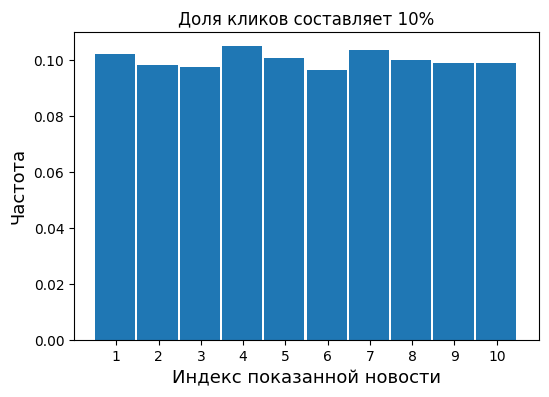

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.hist(df["ActualAction"], width=0.95, bins=[0.5 + x for x in range(11)],
        align='mid', density=True)
_ = ax.set_xticks([x for x in range(1, 11)])
_ = ax.set_xlabel("Индекс показанной новости", fontsize=13)
_ = ax.set_ylabel("Частота", fontsize=13)
ax.set_title(f"Доля кликов составляет {round(100 * np.mean(df['Reward']))}%")

## Идея задания

В этой работе мы исследуем два алгоритма: UCB-1 (разминка) и LinUCB (основное задание).

**Наша задача** Просимулировать обучение алгоритма в *online-режиме* (в порядке прихода пользователей), используя *offline-данные* (мы не знаем, что было бы, если бы для пользователя $t$ мы сделали другое предсказание).

**Наша метрика**  Clickthrough Rate (CTR), то есть доля пользователей, которые кликнули на предложенную новость. Например, CTR случайного правила равен 10% (см. график выше).

**Подход к предсказанию**  Для предсказания новости на шаге $t$ алгоритмы будут использовать всю имеющуюся информацию (все данные из раундов $1, \ldots, t-1$).

**Подход к оценке алгоритма**  Для оценки CTR на момент $t$ мы будем использовать все раунды от 1 до $t$ в которых предсказания алгоритма совпадали с фактически показанными новостями. Введем некоторые обозначения:
- $a_t^*$ -- фактическая новость, показанная в раунде $t$
- $r_t$ -- фактический reward в раунде $t$
- $\hat{a}_t$ -- новость, которую наш алгоритм показал бы в раунде $t$

Тогда для любого раунда $t$ текущий CTR нашего алгоритма подсчитывается следующим образом:
$$\text{CTR}_t = \frac{\sum\limits_{i=1}^t r_i \times \mathbb{I} [a_i^* = \hat{a}_i]}{\sum\limits_{i=1}^t \mathbb{I} [a_i^* = \hat{a}_i]} $$


In [12]:
df

,ActualAction,Reward,F1,F2,F3,F4,F5,F6,F7,F8,...,F91,F92,F93,F94,F95,F96,F97,F98,F99,F100
0,2,0,5,0,0,37,6,0,0,0,...,0,0,1,3,0,0,17,30,4,0
1,8,0,1,3,36,0,0,0,0,0,...,0,0,3,0,1,5,1,0,0,10
2,5,0,3,0,0,0,0,0,0,0,...,0,0,0,0,23,0,11,3,0,0
3,4,0,77,0,0,13,0,0,0,0,...,0,5,0,0,0,2,4,0,0,0
4,2,1,43,0,2,44,1,0,0,0,...,0,0,0,0,0,0,0,13,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,0,0,3,29,0,0,0,0,0,...,0,0,4,0,5,8,1,0,0,9
9996,2,0,1,0,29,0,0,0,0,0,...,0,0,7,0,2,2,0,0,0,13
9997,9,1,79,0,0,17,0,0,0,0,...,0,4,0,1,0,3,9,0,0,0
9998,4,0,29,0,2,44,0,0,0,0,...,2,0,0,0,0,0,0,17,0,0


## Разминка. UCB-1 [2 балла]

Начнем с простого: алгоритма UCB-1.

**Алгоритм UCB-1**

Для начала попробуем использовать алгоритм UCB-1, который игнорирует контексты, то есть считает, что награда в раунде $t$ зависит только от выбранного действия, но не от контекста:
$$r_t \sim \mathcal{P}(a_t).$$

**Псевдокод алгоритма**

Параметр алгоритма: $\alpha$

Шаг 1. Устанавливаем Upper Confidence Bound (UCB) каждой новости в бесконечность

Шаг 2. Для каждого раунда от 1 до T:

- A. Выбираем новость $\hat{a}$ с наибольшей UCB (в случае ничьей выбираем случайно)

- B. Наблюдаем фактически показанную новость $a^*$ и фактический reward $r$

- С. Обновляем UCB новости $a^*$ (так как информацию мы получили по ней):
$$\text{UCB}' = \bar{r_t}(a^*) + \alpha \sqrt{\frac{1}{n_t(a^*)}}$$ Здесь $\bar{r_t}(a^{\ast})$ это CTR новости $a^{\ast}$ на момент $t$, а $n_t(a^*)$ это количество показов новости $a^{\ast}$ на момент $t$

- D. Подсчитываем $\text{CTR}_t$ для нашего алгоритма


**<font color='orange'>Задание</font>**

1. Реализуйте алгоритм UCB-1

2. Обучите алгоритм UCB-1 на наших данных с разными параметрами $\alpha$. Постройте графики $\text{CTR}_t$ для разных параметров на одном рисунке

3. Сравните UCB-1 с случайным алгоритмом

4. Напишите развернутый комментарий, объясняющий пункты 2 и 3. В чем смысла параметра $\alpha$?


In [13]:
df[df['ActualAction'] == 1].ActualAction.count()

np.int64(1020)

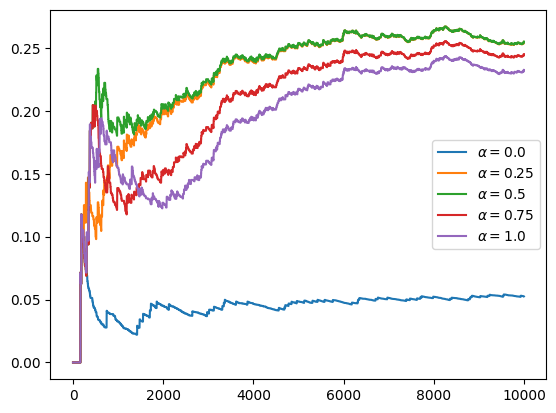

In [20]:
from collections import defaultdict

# асимптотика не особо важна мы тут офлайн алгосы считаем
def get_ucb_index(actions_map): # да, алгос детерменированный, но там норм
    ucr_index = 0
    ucr = -float('inf')
    for x in actions_map:
        if actions_map[x] > ucr:
            ucr = actions_map[x]
            ucr_index = x
    return ucr_index

T = 20
ctr_map = defaultdict(list)
for alpha in np.linspace(0, 1, 5):
    actions_ucb = {i: float('inf') for i in range(1, 11)}
    actions_shown = {i: 1e-9 for i in range(1, 11)}
    actions_reward = {i: 1e-9 for i in range(1, 11)}

    cum_matches = 1e-9
    cum_reward = 0
    for idx, row in df.iterrows():
        actual_action = row['ActualAction']
        reward = row['Reward']

        ucb_index = get_ucb_index(actions_ucb)
        mean_reward = actions_reward[ucb_index] / actions_shown[ucb_index]
        actions_ucb[ucb_index] = mean_reward + alpha * np.sqrt( 1 / actions_shown[ucb_index] )


        if ucb_index == actual_action:
            actions_shown[ucb_index] += 1
            actions_reward[ucb_index] += reward

            cum_matches += 1
            cum_reward += reward

        ctr_map[alpha].append(cum_reward / cum_matches)


for alpha in ctr_map:
    plt.plot(ctr_map[alpha], label=rf'$\alpha = {alpha}$')
plt.legend()
plt.show()

У нас получилось более чем в два раза увеличить CTR, в сравнение с рандомным подходом.

В то время, как алгоритм, основанный на случайносте, показывал ~0.1CTR, у нас получилось набить 0.25.

Параметр $\alpha$ отвечает за то, насколько алгоитм занимается Exploration, а насколько Exploitation. При $\alpha = 0$, алгос превращается буквально в жадник, который отдает предпочтение тому рычагу, который надавал больше реворда. При адекватных $\alpha$ можно было бы ожидать, что на маленьких значениях, будут проигрывать в начале, но выигрывать в конце. Вот у нас так не вышло, но, возможно, просто данные слишком простые Я

## Разминка. UCB-1 [2 балла]

Начнем с простого: алгоритма UCB-1.

**Алгоритм UCB-1**

Для начала попробуем использовать алгоритм UCB-1, который игнорирует контексты, то есть считает, что награда в раунде $t$ зависит только от выбранного действия, но не от контекста:
$$r_t \sim \mathcal{P}(a_t).$$

**Псевдокод алгоритма**

Параметр алгоритма: $\alpha$

Шаг 1. Устанавливаем Upper Confidence Bound (UCB) каждой новости в бесконечность

Шаг 2. Для каждого раунда от 1 до T:

- A. Выбираем новость $\hat{a}$ с наибольшей UCB (в случае ничьей выбираем случайно)

- B. Наблюдаем фактически показанную новость $a^*$ и фактический reward $r$

- С. Обновляем UCB новости $a^*$ (так как информацию мы получили по ней):
$$\text{UCB}' = \bar{r_t}(a^*) + \alpha \sqrt{\frac{1}{n_t(a^*)}}$$ Здесь $\bar{r_t}(a^{\ast})$ это CTR новости $a^{\ast}$ на момент $t$, а $n_t(a^*)$ это количество показов новости $a^{\ast}$ на момент $t$

- D. Подсчитываем $\text{CTR}_t$ для нашего алгоритма


**<font color='orange'>Задание</font>**

1. Реализуйте алгоритм UCB-1

2. Обучите алгоритм UCB-1 на наших данных с разными параметрами $\alpha$. Постройте графики $\text{CTR}_t$ для разных параметров на одном рисунке

3. Сравните UCB-1 с случайным алгоритмом

4. Напишите развернутый комментарий, объясняющий пункты 2 и 3. В чем смысла параметра $\alpha$?


## Основной алгоритм. LinUCB [3 балла]

Теперь реализуем алгоритм, который учитывает контекст ---  LinUCB. Этот алгоритм построен на нескольких основных предположениях/идеях.

**Предположение/идея 1** Будем считатать, что матожидание награды для каждой пары (контекст $x$, действие $a$) определяется линейной моделью:
$$ \mathbb{E}[r | x, a] = x^T \theta_a, $$ где $x \in \mathbb{R}^d$ это вектор контекста,  а $\theta_a \in \mathbb{R}^d$ - неизвестный вектор, описывающий действие $a$ (для каждого действия он свой)

**Предположение/идея 2** Основная идея алгоритма --- попытаться оценить $\theta_a$ в процессе обучения. Для этого применяется линейная модель Ridge Regression.

Пусть в раундах $1, \ldots, t$ действие $a$ было фактически выбрано $m$ раз. Тогда запишем все соответствующие контексты в матрицу $D_a$ размера $m \times d$, а все соответствующие значения reward в вектор $c_a \in R^m$. Теперь применим Ridge Regression для оценки параметра $\theta_a$:
$$\hat{\theta}_a = (D_a^T D_a + I)^{-1} D_a^T c_a$$

**Предположение/идея 3** Аналогично алгоритму UCB-1, в каждом раунде будем выбирать действие с самой оптимистичной верхней границей на матожидание reward:
$$\hat{a}_t = \arg\max\limits_a \left[x^T \hat{\theta}_a + \alpha \sqrt{x^T (D_a^T D_a + I)^{-1} x} \right]$$ Здесь первое слагаемое это оценка мат. ожидания reward от действия $a$ (идея 1), а второе --- оценка дисперсии, следующая из свойств Ridge Regression.

**<font color='orange'>Задание</font>**

1. Реализуйте алгоритм LinUCB

2. Обучите алгоритм LinUCB на наших данных с разными параметрами $\alpha$. Постройте графики $\text{CTR}_t$ для разных параметров на одном рисунке

3. Сравните LinUCB с случайным алгоритмом и UCB-1

4. Напишите развернутый комментарий, объясняющий пункты 2 и 3. В чем смысла параметра $\alpha$?

**Подсказка** Для эффективной имплементации удобно ввести дополнительные матрицу и вектор:
$$A_a =  D_a^T D_a + I, \ b_a = D_a^T c_a.$$

- В таких обозначениях выражения, введенные выше, упрощаются:
$$\hat{\theta}_a = A_a^{-1} b_a $$
$$x^T \hat{\theta}_a + \alpha \sqrt{x^T (D_a^T D_a + I)^{-1} x} = x^T \hat{\theta}_a + \alpha \sqrt{x^T (A_a)^{-1} x} $$

- Новые объекты $A_a$ и $b_a$ легко обновлять после нового наблюдения $(x, a, r)$:
$$A_a' = A_a + x \cdot x^T, b_a' = b_a + r x$$

- Если действие $a$ еще не выбиралось, то матрица $A_a$ задается единичной матрицей, а вектор $b_a$ нулевым вектором

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:53<00:00, 188.53it/s]


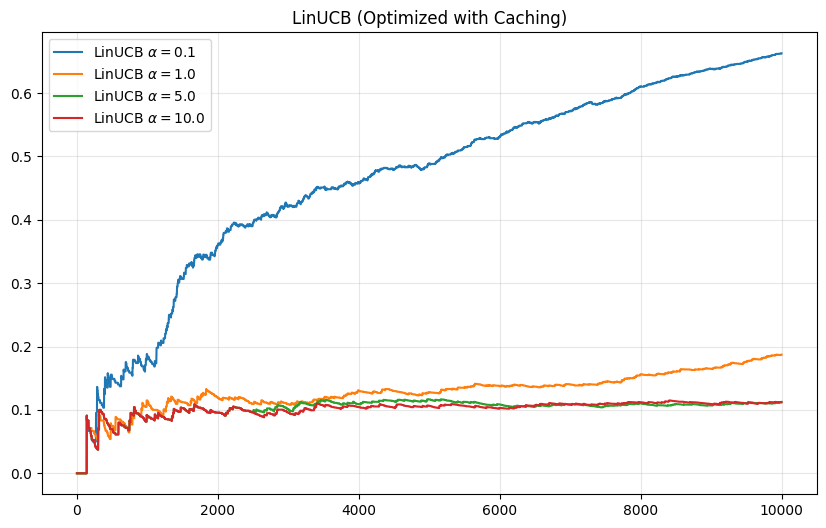

In [28]:
from tqdm import tqdm


feature_cols = [f'F{i}' for i in range(1, 101)]
X_all = df[feature_cols].values.astype(float)
actions_all = df['ActualAction'].values.astype(int)
rewards_all = df['Reward'].values.astype(float)

d = 100
n_arms = 10
alphas = [0.1, 1.0, 5.0, 10.0]
ctr_map_linucb = defaultdict(list)

for alpha in alphas:
    A_map = [np.eye(d) for _ in range(n_arms + 1)]
    b_map = [np.zeros(d) for _ in range(n_arms + 1)]

    A_inv_cache = [np.eye(d) for _ in range(n_arms + 1)]
    theta_cache = [np.zeros(d) for _ in range(n_arms + 1)]

    cum_matches = 0
    cum_reward = 0
    history = []

    T = len(df)
    for t in tqdm(range(T)):
        x = X_all[t]
        actual_action = actions_all[t]
        reward = rewards_all[t]
        max_ucb = -float('inf')
        predicted_action = -1

        for arm in range(1, n_arms + 1):
            theta = theta_cache[arm]
            A_inv = A_inv_cache[arm]
            mean_est = x @ theta
            var_est = np.sqrt(x @ A_inv @ x)
            ucb_score = mean_est + alpha * var_est

            if ucb_score > max_ucb:
                max_ucb = ucb_score
                predicted_action = arm

        if predicted_action == actual_action:
            A_map[predicted_action] += np.outer(x, x)
            b_map[predicted_action] += reward * x

            # тут мы кэшируем чтобы не пересчитывать.

            new_A_inv = np.linalg.inv(A_map[predicted_action])
            new_theta = new_A_inv @ b_map[predicted_action]

            A_inv_cache[predicted_action] = new_A_inv
            theta_cache[predicted_action] = new_theta

            cum_matches += 1
            cum_reward += reward

        current_ctr = cum_reward / cum_matches if cum_matches > 0 else 0
        history.append(current_ctr)

    ctr_map_linucb[alpha] = history

plt.figure(figsize=(10, 6))
for alpha in ctr_map_linucb:
    plt.plot(ctr_map_linucb[alpha], label=rf'LinUCB $\alpha = {alpha}$')
plt.title('LinUCB (Optimized with Caching)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

В сравнении с простым UCB1, у нас получилось добиться значимых преращений: лучший вариант достиг почти 0.7 и продолжал расти. Даже простой линрег позволяет натренировать модельку до значительных результатов.

Параметр $\alpha$ отвечает за то, насколько алгоитм занимается Exploration, а насколько Exploitation. При $\alpha = 0$, алгос превращается буквально в жадник, который отдает предпочтение тому рычагу, который надавал больше реворда. При адекватных $\alpha$ можно было бы ожидать, что на маленьких значениях, будут проигрывать в начале, но выигрывать в конце. Вот у нас так не вышло, но, возможно, просто данные слишком простые.